# Roteiro de Aula: Feature Engineering com banco de dados bancários

Este notebook orienta a prática de Feature Engineering com o arquivo `bank-vf.csv`.
O foco é analisar o dataset, tratar valores faltantes, codificar variáveis categóricas, escalar variáveis numéricas, discretizar, criar novos atributos e selecionar features.

## Objetivos
- Explorar a base `bank-vf.csv` e compreender o significado das variáveis.
- Aplicar tratamento de dados nulos e comparar abordagens.
- Codificar variáveis categóricas usando ordinais e One-Hot.
- Comparar escalonamentos: MinMax, Standard e Robust.
- Discretizar uma variável numérica e interpretar os resultados.
- Criar novos atributos e avaliar sua utilidade.
- Realizar amostragem em base desbalanceada e selecionar features relevantes.

## 1. Carregamento e inspeção inicial
1. Importe `pandas`, `numpy`, `seaborn` e `matplotlib.pyplot`.
2. Carregue `bank-vf.csv` em um DataFrame `df`.
3. Remova a coluna `Unnamed: 0` se ela existir.
4. Exiba `df.head()` e `df.info()`.

### Perguntas
- Quantas linhas e colunas existem no dataset?
- Qual é a variável alvo?
- Quais colunas parecem conter valores faltantes?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/content/bank-vf.csv")

# Remover índice salvo pelo CSV, caso exista.
if "Unnamed: 0" in df.columns:
    df = df.drop(columns="Unnamed: 0")

if "y" not in df.columns:
    raise ValueError("A variável alvo 'y' não foi encontrada na base.")

In [2]:
print(f"Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
display(df.head())


Dimensões: 45,211 linhas x 17 colunas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,NaN,management,NaN,tertiary,no,2143.0,yes,no,NaN,5.0,may,NaN,1.0,-1.0,0.0,NaN,no
1,44.0,technician,single,secondary,no,29.0,yes,no,NaN,5.0,may,151.0,1.0,-1.0,0.0,NaN,no
2,NaN,entrepreneur,married,secondary,no,2.0,yes,yes,NaN,5.0,may,NaN,1.0,-1.0,0.0,NaN,no
3,47.0,blue-collar,married,NaN,no,1506.0,yes,no,NaN,5.0,may,92.0,1.0,-1.0,0.0,NaN,no
4,NaN,NaN,single,NaN,no,1.0,no,no,NaN,5.0,may,198.0,1.0,NaN,0.0,NaN,no


In [3]:
print("\nTipos de dados:")
display(df.dtypes.to_frame("dtype"))


Tipos de dados:


,dtype
age,float64
job,object
marital,object
education,object
default,object
balance,float64
housing,object
loan,object
contact,object
day,float64


In [4]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos"))


Valores ausentes por coluna:


,nulos
poutcome,36959
marital,20239
duration,18291
balance,15636
age,15581
contact,13020
pdays,9775
previous,6240
education,1857
job,288


In [5]:
print('Informações do DataFrame:\n')
print(df.info())

Informações do DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        29630 non-null  float64
 1   job        44923 non-null  object 
 2   marital    24972 non-null  object 
 3   education  43354 non-null  object 
 4   default    45211 non-null  object 
 5   balance    29575 non-null  float64
 6   housing    45211 non-null  object 
 7   loan       45211 non-null  object 
 8   contact    32191 non-null  object 
 9   day        45211 non-null  float64
 10  month      45211 non-null  object 
 11  duration   26920 non-null  float64
 12  campaign   45211 non-null  float64
 13  pdays      35436 non-null  float64
 14  previous   38971 non-null  float64
 15  poutcome   8252 non-null   object 
 16  y          45211 non-null  object 
dtypes: float64(7), object(10)
memory usage: 5.9+ MB
None


## 2. Divisão treino/teste estratificada
1. Divida a base em treino e teste antes de qualquer tratamento de dados.
2. Use `train_test_split(..., stratify=df['y'], random_state=42)` para preservar a proporção da variável resposta.
3. Mantenha todo o pré-processamento e engenharia de features apenas no conjunto de treino.
4. Reserve `df_test` como conjunto de validação final e não o utilize durante o ajuste de imputadores, encoders ou scalers.

### Observação
- A partir desta etapa, `df` representa o conjunto de treino (`df_train`).
- `df_test` deve ser usado apenas para avaliação final após todas as transformações serem definidas.

In [6]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["y"],
    random_state=42
)

print("Treino:", df_train.shape)
print("Teste :", df_test.shape)

Treino: (36168, 17)
Teste : (9043, 17)


In [7]:
print("\nDistribuição de y:\n")
distribuicao = pd.DataFrame({
    "treino": df_train["y"].value_counts(normalize=True),
    "teste": df_test["y"].value_counts(normalize=True)
})
display(distribuicao)


Distribuição de y:



,treino,teste
y,,
no,0.883018,0.883003
yes,0.116982,0.116997


## 3. EDA automatizada com ydata-profiling
1. Instale `ydata-profiling` e gere um relatório exploratório automatizado.
2. Verifique alertas de dados faltantes, variáveis constantes, correlações altas e possíveis outliers.
3. Revise as estatísticas de cada coluna antes de aplicar imputação e codificação.
4. Use o relatório para orientar a seleção de técnicas de pré-processamento.

### Exemplo de código
```python
# !pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df_train, title='Relatório EDA - bank-vf', explorative=True, minimal=True)
profile.to_file('relatorio_eda_bank_vf.html')
profile.to_notebook_iframe()
```

In [8]:
#%pip uninstall -y ydata-profiling scipy numpy
#%pip install --no-cache-dir numpy scipy ydata-profiling

In [9]:
#!python.exe -m pip install --upgrade pip

In [10]:
#%pip install ydata-profiling

In [11]:
#%pip install ipywidgets

In [12]:
# Opcional: execute somente se o pacote estiver disponível no ambiente.
try:
    from ydata_profiling import ProfileReport

    profile = ProfileReport(
        df_train,
        title="Relatório EDA - bank-vf",
        minimal=True
    )
    profile.to_file("relatorio_eda_bank_vf.html")
    display(profile.to_notebook_iframe())
except ImportError:
    print(
        "ydata-profiling não está instalado. "
        "A EDA manual das próximas seções será usada."
    )
except Exception as exc:
    print(f"Não foi possível gerar o relatório automaticamente: {exc}")

/tmp/ipykernel_29475/3748583112.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:01<00:00, 13.94it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

None

## 4. Análise de valores faltantes
1. Verifique a quantidade de nulos em cada coluna com `df_train.isnull().sum()`.
2. Visualize a estrutura de nulos usando `missingno` ou gráficos simples.
3. Decida quais colunas precisam de tratamento no conjunto de treino.

### Perguntas
- Quais colunas têm mais valores faltantes?
- É adequado usar imputação por mediana em todas as colunas numéricas?
- Como tratar colunas categóricas com valores faltantes?

In [13]:
missing = pd.DataFrame({
    "nulos": df_train.isna().sum(),
    "percentual": df_train.isna().mean().mul(100)
}).sort_values("percentual", ascending=False)

display(missing)

,nulos,percentual
poutcome,29589,81.809887
marital,16230,44.873922
duration,14658,40.527538
balance,12513,34.596881
age,12464,34.461402
contact,10386,28.715992
pdays,7809,21.590909
previous,4990,13.796726
education,1482,4.097545
job,234,0.646981


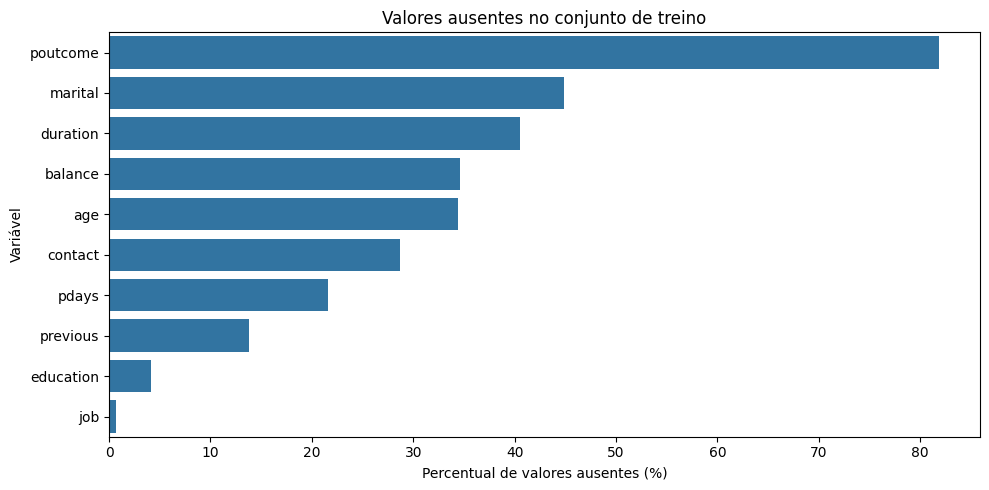

In [14]:
plt.figure(figsize=(10, 5))
missing_nonzero = missing[missing["nulos"] > 0]
sns.barplot(
    data=missing_nonzero.reset_index(),
    x="percentual",
    y="index"
)
plt.xlabel("Percentual de valores ausentes (%)")
plt.ylabel("Variável")
plt.title("Valores ausentes no conjunto de treino")
plt.tight_layout()
plt.show()

## 5. Tratamento de valores ausentes
1. Crie duas cópias do DataFrame: `df_simple` e `df_knn`.
2. Em `df_simple`, use `SimpleImputer` para preencher numéricos com a mediana e categóricos com a moda.
3. Em `df_knn`, preencha categorias com moda, transforme em dummy e aplique `KNNImputer`.
4. Compare a distribuição de uma variável numérica como `age` ou `balance` entre as abordagens.

### Perguntas
- Qual método preserva melhor a distribuição original?
- Quais são as limitações do `KNNImputer`?

In [15]:
from sklearn.impute import SimpleImputer, KNNImputer

df_simple = df_train.copy()
df_knn = df_train.copy()

cols_num = df_train.select_dtypes(include=np.number).columns.tolist()
cols_cat = df_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Estratégia 1: mediana para numéricas e moda para categóricas.
imputer_num_simple = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="most_frequent")

df_simple[cols_num] = imputer_num_simple.fit_transform(df_train[cols_num])
df_simple[cols_cat] = imputer_cat.fit_transform(df_train[cols_cat])

# Estratégia 2: KNN para numéricas e moda para categóricas.
imputer_num_knn = KNNImputer(n_neighbors=5, weights="distance")
df_knn[cols_num] = imputer_num_knn.fit_transform(df_train[cols_num])
df_knn[cols_cat] = imputer_cat.fit_transform(df_train[cols_cat])

print("Nulos após SimpleImputer:", int(df_simple.isna().sum().sum()))
print("Nulos após KNNImputer   :", int(df_knn.isna().sum().sum()))


Nulos após SimpleImputer: 0
Nulos após KNNImputer   : 0


In [16]:
comparacao = pd.DataFrame({
    "original": df_train[cols_num].median(),
    "simple_mediana": df_simple[cols_num].median(),
    "knn": df_knn[cols_num].median()
})
display(comparacao)

,original,simple_mediana,knn
age,39.0,39.0,40.0
balance,457.0,457.0,647.2
day,16.0,16.0,16.0
duration,180.0,180.0,207.0
campaign,2.0,2.0,2.0
pdays,-1.0,-1.0,-1.0
previous,0.0,0.0,0.0


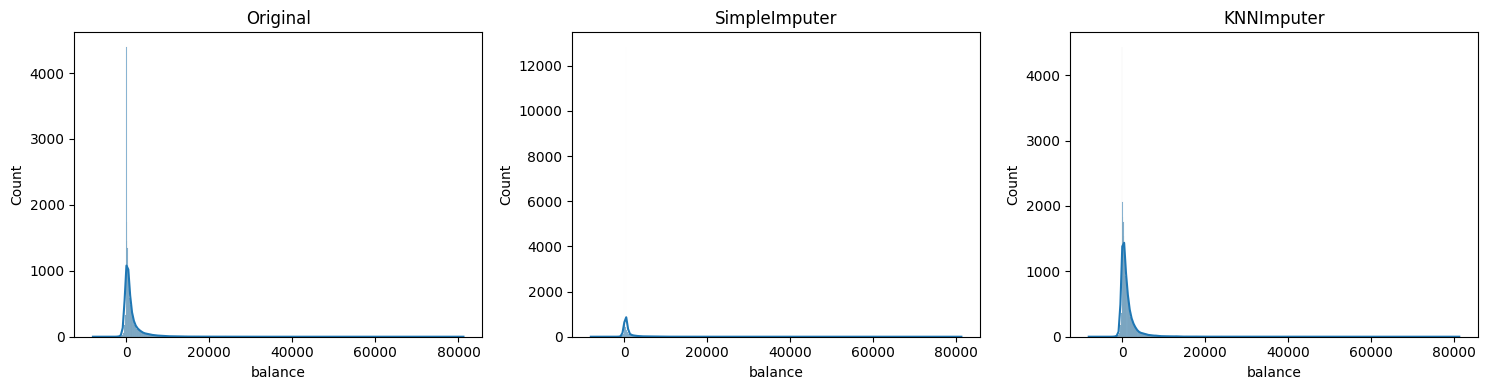

In [17]:
# Comparação visual de uma variável numérica.
variavel = "balance"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_train[variavel], kde=True, ax=axes[0])
axes[0].set_title("Original")

sns.histplot(df_simple[variavel], kde=True, ax=axes[1])
axes[1].set_title("SimpleImputer")

sns.histplot(df_knn[variavel], kde=True, ax=axes[2])
axes[2].set_title("KNNImputer")

plt.tight_layout()
plt.show()

## 6. Encoding de variáveis categóricas
1. Identifique as colunas categóricas e determine quais podem receber `OrdinalEncoder`.
2. Use `OneHotEncoder` para as demais variáveis.
3. Crie um `ColumnTransformer` que mantenha colunas numéricas e transforme as categóricas.
4. Exporte um DataFrame codificado e compare formas de codificação.

### Perguntas
- Qual a diferença entre ordinal e one-hot encoding?
- Quando o `OrdinalEncoder` pode introduzir ordens falsas?

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Separação entre preditores e alvo.
X_train_raw = df_train.drop(columns="y").copy()
y_train = df_train["y"].map({"no": 0, "yes": 1})

if y_train.isna().any():
    raise ValueError("A variável y contém categorias diferentes de 'no'/'yes'.")

# Imputação dentro do fluxo de treino.
cols_numericas = X_train_raw.select_dtypes(include=np.number).columns.tolist()
cols_categoricas = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()

cols_ordinais = ["education"] if "education" in cols_categoricas else []
cols_nominais = [c for c in cols_categoricas if c not in cols_ordinais]

education_order = ["primary", "secondary", "tertiary"]

transformers = []

In [19]:
if cols_ordinais:
    transformers.append((
        "ordinal",
        # A imputação categórica ocorre antes do encoder.
        __import__("sklearn").pipeline.Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                categories=[education_order],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]),
        cols_ordinais
    ))

if cols_nominais:
    transformers.append((
        "onehot",
        __import__("sklearn").pipeline.Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            ))
        ]),
        cols_nominais
    ))

if cols_numericas:
    transformers.append((
        "numeric",
        SimpleImputer(strategy="median"),
        cols_numericas
    ))


In [20]:
preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_encoded = preprocessor.fit_transform(X_train_raw)

feature_names = preprocessor.get_feature_names_out()
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train_raw.index
)

In [21]:
print(f"Features antes do encoding: {X_train_raw.shape[1]}")
print(f"Features depois do encoding: {X_train_encoded.shape[1]}\n")
display(X_train_encoded.head())

Features antes do encoding: 16
Features depois do encoding: 37



,education,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_sep,poutcome_other,poutcome_success,age,balance,day,duration,campaign,pdays,previous
24001,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,36.0,861.0,29.0,140.0,2.0,-1.0,0.0
43409,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,39.0,4126.0,5.0,907.0,4.0,185.0,0.0
20669,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,44.0,457.0,12.0,180.0,4.0,-1.0,0.0
18810,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,48.0,457.0,31.0,35.0,11.0,-1.0,0.0
23130,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,38.0,457.0,26.0,57.0,10.0,-1.0,0.0


## 7. Escalonamento de dados numéricos
1. Use `MinMaxScaler`, `StandardScaler` e `RobustScaler` em um mesmo conjunto numérico.
2. Compare a distribuição de pelo menos uma variável após cada scaler.
3. Registre as vantagens e desvantagens de cada método.

### Perguntas
- Qual scaler é mais sensível a outliers?
- Para que tipo de modelo cada scaler é recomendado?

In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

scalers = {
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
    "Robust": RobustScaler()
}

scaled_frames = {}

for nome, scaler in scalers.items():
    values = scaler.fit_transform(X_train_encoded[cols_numericas])
    scaled_frames[nome] = pd.DataFrame(
        values,
        columns=cols_numericas,
        index=X_train_encoded.index
    )


In [23]:
display(scaled_frames["MinMax"][["balance", "duration"]].head())

,balance,duration
24001,0.099526,0.028072
43409,0.136120,0.184093
20669,0.094998,0.036208
18810,0.094998,0.006713
23130,0.094998,0.011188


In [24]:
display(scaled_frames["Standard"][["balance", "duration"]].head())

,balance,duration
24001,-0.076067,-0.426621
43409,1.207452,3.373374
20669,-0.234885,-0.228447
18810,-0.234885,-0.946829
23130,-0.234885,-0.837833


In [25]:
display(scaled_frames["Robust"][["balance", "duration"]].head())

,balance,duration
24001,0.770992,-0.677966
43409,7.001908,12.322034
20669,0.000000,0.000000
18810,0.000000,-2.457627
23130,0.000000,-2.084746


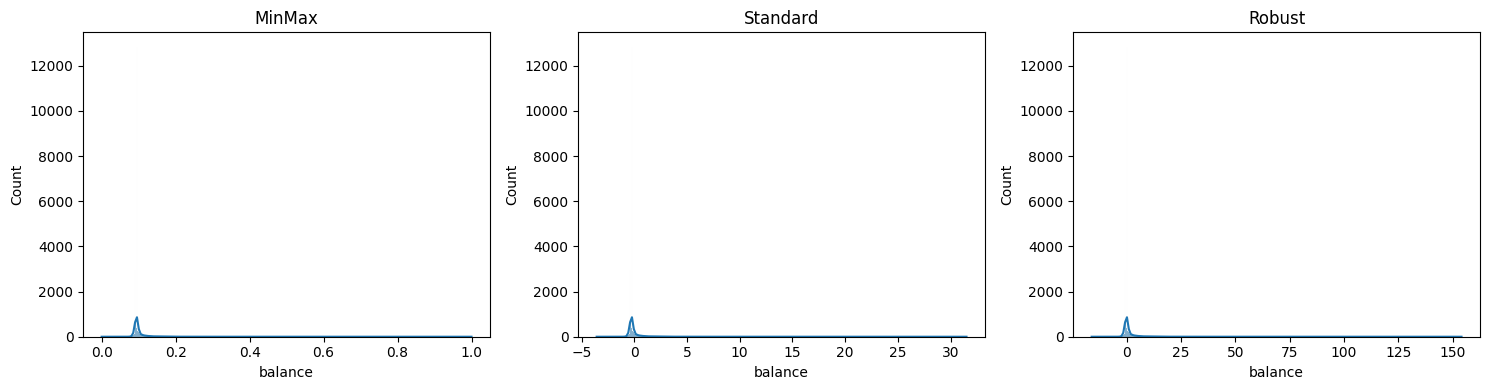

In [26]:
# Comparação gráfica para uma variável com potencial de valores extremos.
variavel = "balance"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, frame) in zip(axes, scaled_frames.items()):
    sns.histplot(frame[variavel], kde=True, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel(variavel)

plt.tight_layout()
plt.show()

## 8. Discretização de variáveis numéricas
1. Escolha a variável `duration` ou `balance` para discretizar.
2. Aplique `KBinsDiscretizer` com estratégias `uniform`, `quantile` e `kmeans`.
3. Analise como cada método agrupa os valores.

### Perguntas
- Qual estratégia é mais útil quando há muitos valores extremos?
- A discretização ajuda a reduzir o impacto de outliers?

In [27]:
from sklearn.preprocessing import KBinsDiscretizer

coluna = X_train_encoded[["balance"]]

discretizadores = {
    "uniform": KBinsDiscretizer(
        n_bins=5, encode="ordinal", strategy="uniform"
    ),
    "quantile": KBinsDiscretizer(
        n_bins=5, encode="ordinal", strategy="quantile"
    ),
    "kmeans": KBinsDiscretizer(
        n_bins=5, encode="ordinal", strategy="kmeans"
    )
}

df_bins = pd.DataFrame({"balance_original": coluna["balance"]})

for nome, discretizador in discretizadores.items():
    df_bins[f"balance_{nome}"] = discretizador.fit_transform(coluna).ravel()

display(df_bins.head(10))
print("\nQuantidade de observações por bin:")
display(df_bins.drop(columns="balance_original").apply(pd.Series.value_counts).fillna(0).astype(int))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


,balance_original,balance_uniform,balance_quantile,balance_kmeans
24001,861.0,0.0,2.0,0.0
43409,4126.0,0.0,3.0,1.0
20669,457.0,0.0,2.0,0.0
18810,457.0,0.0,2.0,0.0
23130,457.0,0.0,2.0,0.0
15058,1513.0,0.0,3.0,0.0
15908,4315.0,0.0,3.0,1.0
30424,-780.0,0.0,0.0,0.0
9998,474.0,0.0,2.0,0.0
14935,457.0,0.0,2.0,0.0



Quantidade de observações por bin:


,balance_uniform,balance_quantile,balance_kmeans
0.0,35725,7231,31371
1.0,400,4596,3627
2.0,29,17106,962
3.0,10,7235,179
4.0,4,0,29


## 9. Criação de novos atributos
1. Crie um novo atributo a partir de duas variáveis numéricas, por exemplo `balance / (duration + 1)` ou `campaign * duration`.
2. Explique a hipótese de negócio por trás desse novo atributo.
3. Analise a correlação do novo atributo com a variável alvo.

### Perguntas
- Sua nova feature é informativa?
- Há risco de vazamento de dados? Por quê?

In [42]:
df_train_fe = df_train.copy()

df_train_fe["balance_duration_ratio"] = (
    (df_train_fe["balance"] + 1) /
    (df_train_fe["duration"] + 1)
)

display(
    df_train_fe[["balance", "duration", "balance_duration_ratio"]]
    .describe()
)

# Correlação simples com o alvo binário.
target_numeric = df_train_fe["y"].map({"no": 0, "yes": 1})
corr = df_train_fe["balance_duration_ratio"].corr(target_numeric)

print(f"\nCorrelação linear com y: {corr:.4f}")

,balance,duration,balance_duration_ratio
count,23655.000000,21510.000000,14101.000000
mean,1370.561530,257.532032,12.326443
std,3099.269732,257.040360,53.442581
min,-8019.000000,2.000000,-180.000000
25%,75.000000,103.000000,0.334975
50%,457.000000,180.000000,2.320819
75%,1430.000000,318.000000,8.682927
max,81204.000000,4918.000000,2505.222222



Correlação linear com y: -0.0413


### Atualização do conjunto de features

Como a nova variável foi criada **depois** do primeiro encoding, ela precisa ser incorporada ao conjunto de preditores antes de balanceamento e seleção de features.

A etapa abaixo refaz o pré-processamento incluindo a nova coluna.


In [29]:
X_train_fe = df_train_fe.drop(columns="y").copy()

cols_numericas_fe = X_train_fe.select_dtypes(include=np.number).columns.tolist()
cols_categoricas_fe = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()

cols_ordinais_fe = ["education"] if "education" in cols_categoricas_fe else []
cols_nominais_fe = [c for c in cols_categoricas_fe if c not in cols_ordinais_fe]

transformers_fe = []

In [30]:
if cols_ordinais_fe:
    transformers_fe.append((
        "ordinal",
        __import__("sklearn").pipeline.Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                categories=[education_order],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]),
        cols_ordinais_fe
    ))

if cols_nominais_fe:
    transformers_fe.append((
        "onehot",
        __import__("sklearn").pipeline.Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            ))
        ]),
        cols_nominais_fe
    ))


In [31]:
transformers_fe.append((
    "numeric",
    SimpleImputer(strategy="median"),
    cols_numericas_fe
))

preprocessor_fe = ColumnTransformer(
    transformers=transformers_fe,
    remainder="drop",
    verbose_feature_names_out=False
)

X_fe = pd.DataFrame(
    preprocessor_fe.fit_transform(X_train_fe),
    columns=preprocessor_fe.get_feature_names_out(),
    index=X_train_fe.index
)

y_fe = df_train_fe["y"].map({"no": 0, "yes": 1})

In [32]:
print("Shape após inclusão da nova feature:", X_fe.shape, "\n")
display(X_fe.head())

Shape após inclusão da nova feature: (36168, 38) 



,education,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,poutcome_other,poutcome_success,age,balance,day,duration,campaign,pdays,previous,balance_duration_ratio
24001,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,36.0,861.0,29.0,140.0,2.0,-1.0,0.0,6.113475
43409,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,39.0,4126.0,5.0,907.0,4.0,185.0,0.0,4.545154
20669,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,44.0,457.0,12.0,180.0,4.0,-1.0,0.0,2.320819
18810,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,48.0,457.0,31.0,35.0,11.0,-1.0,0.0,2.320819
23130,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,38.0,457.0,26.0,57.0,10.0,-1.0,0.0,2.320819


## 10. Amostragem em base desbalanceada
1. Verifique o balanceamento da variável alvo `y`.
2. Use `RandomUnderSampler` e `SMOTE` para gerar bases balanceadas.
3. Compare o tamanho e a distribuição de cada base.

### Perguntas
- Qual técnica preserva mais informação?
- Quando é melhor usar undersampling em vez de oversampling?

In [33]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

print("Distribuição original:")
display(y_fe.value_counts().rename(index={0: "no", 1: "yes"}))

print("\nProporção original:")
display(y_fe.value_counts(normalize=True).rename(index={0: "no", 1: "yes"}))

Distribuição original:


,count
y,
no,31937
yes,4231



Proporção original:


,proportion
y,
no,0.883018
yes,0.116982


In [34]:
undersampler = RandomUnderSampler(random_state=42)
X_under, y_under = undersampler.fit_resample(X_fe, y_fe)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_fe, y_fe)

resumo_balanceamento = pd.DataFrame({
    "Base": ["Original", "RandomUnderSampler", "SMOTE"],
    "Total": [len(y_fe), len(y_under), len(y_smote)],
    "Classe 0 (no)": [
        (y_fe == 0).sum(),
        (y_under == 0).sum(),
        (y_smote == 0).sum()
    ],
    "Classe 1 (yes)": [
        (y_fe == 1).sum(),
        (y_under == 1).sum(),
        (y_smote == 1).sum()
    ]
})

display(resumo_balanceamento)

,Base,Total,Classe 0 (no),Classe 1 (yes)
0,Original,36168,31937,4231
1,RandomUnderSampler,8462,4231,4231
2,SMOTE,63874,31937,31937


## 11. Seleção de features
1. Aplique `SelectKBest` ou `chi2` para seleção filtro.
2. Aplique `RFE` para seleção wrapper.
3. Aplique `SelectFromModel` com `RandomForestClassifier` ou `LogisticRegression` para seleção embarcada.
4. Compare as listas de features selecionadas.

### Perguntas
- Quais features aparecem em mais de um método?
- O método escolhido depende do tipo de modelo?

In [35]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

X_features = X_fe.copy()
y_features = y_fe.copy()

k = min(10, X_features.shape[1])

In [36]:
# 1. Filtro: SelectKBest
selector_kbest = SelectKBest(score_func=f_classif, k=k)
selector_kbest.fit(X_features, y_features)
features_kbest = X_features.columns[selector_kbest.get_support()].tolist()

In [37]:
# 2. Wrapper: RFE
scaler_rfe = StandardScaler()
X_scaled = scaler_rfe.fit_transform(X_features)

modelo_rfe = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

selector_rfe = RFE(
    estimator=modelo_rfe,
    n_features_to_select=k,
    step=0.2
)
selector_rfe.fit(X_scaled, y_features)
features_rfe = X_features.columns[selector_rfe.get_support()].tolist()


In [38]:
# 3. Embarcado: Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

selector_sfm = SelectFromModel(
    estimator=modelo_rf,
    threshold=-np.inf,
    max_features=k
)
selector_sfm.fit(X_features, y_features)
features_sfm = X_features.columns[selector_sfm.get_support()].tolist()

In [39]:
comparacao = pd.DataFrame({
    "SelectKBest": pd.Series(features_kbest),
    "RFE": pd.Series(features_rfe),
    "SelectFromModel": pd.Series(features_sfm)
})

display(comparacao)

,SelectKBest,RFE,SelectFromModel
0,job_retired,housing_yes,housing_yes
1,housing_yes,month_aug,poutcome_success
2,month_mar,month_jul,age
3,month_may,month_jun,balance
4,month_oct,month_may,day
5,month_sep,month_nov,duration
6,poutcome_success,poutcome_success,campaign
7,duration,duration,pdays
8,pdays,campaign,previous
9,previous,balance_duration_ratio,balance_duration_ratio


In [40]:
print("Features em comum entre os três métodos:")
comuns = sorted(set(features_kbest) & set(features_rfe) & set(features_sfm))
print(comuns)

Features em comum entre os três métodos:
['duration', 'housing_yes', 'poutcome_success']


In [43]:
print("Distribuição de y no treino:")
display(df_train["y"].value_counts(normalize=True).rename("proporção"))

print("\nDistribuição de y no teste:")
display(df_test["y"].value_counts(normalize=True).rename("proporção"))

Distribuição de y no treino:


,proporção
y,
no,0.883018
yes,0.116982



Distribuição de y no teste:


,proporção
y,
no,0.883003
yes,0.116997


In [44]:
print("\nChecagens finais:")
print("✓ treino/teste separados antes do pré-processamento")
print("✓ imputação ajustada no treino")
print("✓ encoders ajustados no treino")
print("✓ scalers ajustados no treino")
print("✓ discretização ajustada no treino")
print("✓ balanceamento aplicado somente ao treino")
print("✓ seleção de features ajustada no treino")


Checagens finais:
✓ treino/teste separados antes do pré-processamento
✓ imputação ajustada no treino
✓ encoders ajustados no treino
✓ scalers ajustados no treino
✓ discretização ajustada no treino
✓ balanceamento aplicado somente ao treino
✓ seleção de features ajustada no treino


## 12. Conclusão
Descreva brevemente as escolhas feitas durante o processo de Feature Engineering e o que você aprendeu com a comparação de técnicas.